In [ ]:
!pip install ultralytics
!pip install deep-sort-realtime
!pip install opencv-python

In [ ]:
import cv2
from ultralytics import YOLO
from deep_sort_realtime.deepsort_tracker import DeepSort

In [ ]:
model = YOLO("yolov8n.pt")

In [ ]:
tracker = DeepSort(
    max_age=30,
    n_init=3,
    max_cosine_distance=0.3
)

In [ ]:
video_path = "videos/fourway.avi"

cap = cv2.VideoCapture(video_path)

In [ ]:
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

In [ ]:
out = cv2.VideoWriter(
    'output_tracking.mp4',
    cv2.VideoWriter_fourcc(*'mp4v'),
    fps,
    (width, height)
)

In [ ]:
while True:

    ret, frame = cap.read()

    if not ret:
        break

    # YOLO Detection
    results = model(frame)

    detections = []

    for result in results:

        boxes = result.boxes

        for box in boxes:

            cls = int(box.cls[0])

            # COCO class 0 = person
            if cls == 0:

                x1, y1, x2, y2 = box.xyxy[0]

                conf = float(box.conf[0])

                w = x2 - x1
                h = y2 - y1

                detections.append(
                    ([int(x1), int(y1), int(w), int(h)],
                     conf,
                     'person')
                )

    # DeepSORT Tracking
    tracks = tracker.update_tracks(
        detections,
        frame=frame
    )

    for track in tracks:

        if not track.is_confirmed():
            continue

        track_id = track.track_id

        ltrb = track.to_ltrb()

        x1, y1, x2, y2 = map(int, ltrb)

        # Draw Bounding Box
        cv2.rectangle(
            frame,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        # Display ID
        cv2.putText(
            frame,
            f"ID: {track_id}",
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2
        )

    # Show Frame
    cv2.imshow("Pedestrian Tracking", frame)

    # Save Output
    out.write(frame)

    # Exit on Q
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

In [ ]:
cap.release()
out.release()
cv2.destroyAllWindows()

In [ ]:
from IPython.display import Video

Video("output_tracking.mp4", embed=True)

Dataset folder found successfully
Total Images Found: 170
Testing Image: dataset\PNGImages\FudanPed00001.png

image 1/1 C:\Users\HP\anaconda3\nitw impl\project\dataset\PNGImages\FudanPed00001.png: 640x640 2 persons, 508.1ms
Speed: 25.6ms preprocess, 508.1ms inference, 34.3ms postprocess per image at shape (1, 3, 640, 640)


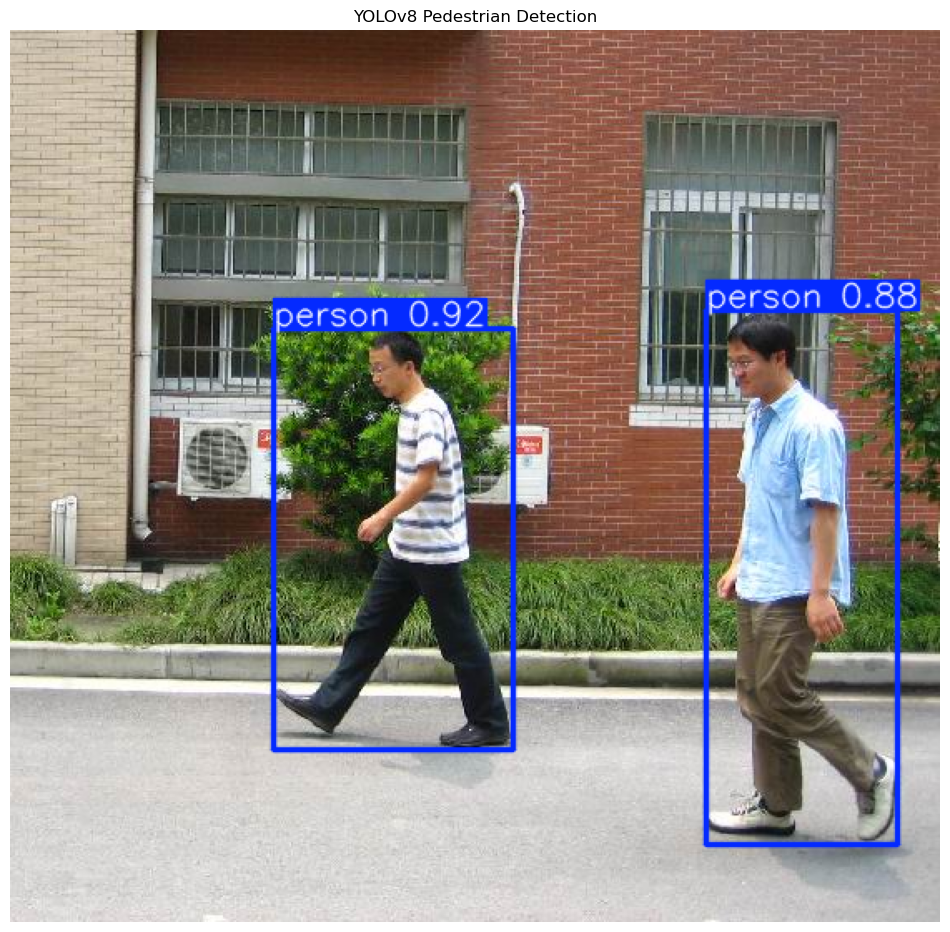

In [2]:
# =========================================================
# YOLOv8 Pedestrian Detection on PennFudanPed Dataset
# Jupyter Notebook Complete Code
# =========================================================

# STEP 1: Install Required Libraries
!pip install ultralytics opencv-python matplotlib -q

# =========================================================
# STEP 2: Import Libraries
# =========================================================

import os
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# =========================================================
# STEP 3: GIVE YOUR DATASET PATH
# =========================================================

# Your PNGImages folder path
image_folder = "dataset\PNGImages"

# =========================================================
# STEP 4: CHECK PATH EXISTS
# =========================================================

if os.path.exists(image_folder):
    print("Dataset folder found successfully")
else:
    print("Wrong path! Check folder location")

# =========================================================
# STEP 5: LOAD YOLOv8 MODEL
# =========================================================

model = YOLO("yolov8n.pt")

# =========================================================
# STEP 6: LOAD IMAGE FILES
# =========================================================

image_files = [f for f in os.listdir(image_folder)
               if f.endswith(".png") or f.endswith(".jpg")]

print("Total Images Found:", len(image_files))

# =========================================================
# STEP 7: SELECT IMAGE
# =========================================================

image_path = os.path.join(image_folder, image_files[0])

print("Testing Image:", image_path)

# =========================================================
# STEP 8: RUN YOLOv8 DETECTION
# =========================================================

results = model(image_path)

# =========================================================
# STEP 9: GET OUTPUT IMAGE
# =========================================================

annotated_frame = results[0].plot()

# =========================================================
# STEP 10: DISPLAY OUTPUT
# =========================================================

plt.figure(figsize=(12,12))
plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("YOLOv8 Pedestrian Detection")
plt.show()

In [13]:
from ultralytics import YOLO

# Load trained model
model = YOLO(r"runs/detect/train-2/weights/best.pt")

# Run detection on images folder
results = model.predict(
    source=r"C:\Users\HP\anaconda3\nitw impl\project\dataset\PNGImages",
    save=True,
    show=True
)


image 1/170 C:\Users\HP\anaconda3\nitw impl\project\dataset\PNGImages\FudanPed00001.png: 640x640 2 persons, 413.5ms
image 2/170 C:\Users\HP\anaconda3\nitw impl\project\dataset\PNGImages\FudanPed00002.png: 608x640 2 persons, 446.9ms
image 3/170 C:\Users\HP\anaconda3\nitw impl\project\dataset\PNGImages\FudanPed00003.png: 608x640 1 person, 430.4ms
image 4/170 C:\Users\HP\anaconda3\nitw impl\project\dataset\PNGImages\FudanPed00004.png: 640x640 3 persons, 377.2ms
image 5/170 C:\Users\HP\anaconda3\nitw impl\project\dataset\PNGImages\FudanPed00005.png: 640x640 2 persons, 367.3ms
image 6/170 C:\Users\HP\anaconda3\nitw impl\project\dataset\PNGImages\FudanPed00006.png: 640x608 2 persons, 414.0ms
image 7/170 C:\Users\HP\anaconda3\nitw impl\project\dataset\PNGImages\FudanPed00007.png: 480x640 3 persons, 445.7ms
image 8/170 C:\Users\HP\anaconda3\nitw impl\project\dataset\PNGImages\FudanPed00008.png: 640x576 2 persons, 399.8ms
image 9/170 C:\Users\HP\anaconda3\nitw impl\project\dataset\PNGImages\Fu

In [11]:
# =========================================================
# COMPLETE YOLOv8 TRAINING CODE FOR PennFudanPed DATASET
# FIXED VERSION (TRAIN + VAL ERROR SOLVED)
# Runs in Jupyter Notebook
# =========================================================

# =========================================================
# STEP 1: INSTALL REQUIRED LIBRARIES
# =========================================================

!pip install ultralytics opencv-python matplotlib -q

# =========================================================
# STEP 2: IMPORT LIBRARIES
# =========================================================

import os
import cv2
import re
import random
import shutil
from glob import glob
from ultralytics import YOLO

# =========================================================
# STEP 3: DATASET PATH
# =========================================================

dataset_path = r"C:\Users\HP\anaconda3\nitw impl\project\dataset"

images_path = os.path.join(dataset_path, "PNGImages")
annotations_path = os.path.join(dataset_path, "Annotation")

print("Images Path:", images_path)
print("Annotations Path:", annotations_path)

# =========================================================
# STEP 4: CREATE YOLO DATASET FOLDERS
# =========================================================

os.makedirs("yolo_dataset/images/train", exist_ok=True)
os.makedirs("yolo_dataset/images/val", exist_ok=True)

os.makedirs("yolo_dataset/labels/train", exist_ok=True)
os.makedirs("yolo_dataset/labels/val", exist_ok=True)

print("YOLO folders created")

# =========================================================
# STEP 5: GET ALL IMAGE FILES
# =========================================================

image_files = glob(os.path.join(images_path, "*.png"))

print("Total Images Found:", len(image_files))

# =========================================================
# STEP 6: SHUFFLE AND SPLIT DATASET
# =========================================================

random.shuffle(image_files)

split_index = int(len(image_files) * 0.8)

train_files = image_files[:split_index]
val_files = image_files[split_index:]

print("Training Images:", len(train_files))
print("Validation Images:", len(val_files))

# =========================================================
# STEP 7: FUNCTION TO CONVERT ANNOTATIONS
# =========================================================

def convert_to_yolo(image_file, save_image_folder, save_label_folder):

    file_name = os.path.basename(image_file).replace(".png", "")

    annotation_file = os.path.join(
        annotations_path,
        file_name + ".txt"
    )

    # Read image
    image = cv2.imread(image_file)

    h, w, _ = image.shape

    yolo_lines = []

    # Read annotation file
    with open(annotation_file, "r") as f:
        lines = f.readlines()

    # Extract bounding boxes
    for line in lines:

        match = re.search(
            r"\((\d+),\s*(\d+)\)\s*-\s*\((\d+),\s*(\d+)\)",
            line
        )

        if match:

            x1, y1, x2, y2 = map(int, match.groups())

            # YOLO format conversion
            x_center = ((x1 + x2) / 2) / w
            y_center = ((y1 + y2) / 2) / h
            box_width = (x2 - x1) / w
            box_height = (y2 - y1) / h

            # Class ID = 0 (person)
            yolo_lines.append(
                f"0 {x_center} {y_center} {box_width} {box_height}"
            )

    # Save label file
    label_file = os.path.join(
        save_label_folder,
        file_name + ".txt"
    )

    with open(label_file, "w") as f:
        f.write("\n".join(yolo_lines))

    # Copy image
    shutil.copy(
        image_file,
        os.path.join(
            save_image_folder,
            os.path.basename(image_file)
        )
    )

# =========================================================
# STEP 8: CREATE TRAIN DATA
# =========================================================

for image_file in train_files:

    convert_to_yolo(
        image_file,
        "yolo_dataset/images/train",
        "yolo_dataset/labels/train"
    )

print("Training dataset prepared")

# =========================================================
# STEP 9: CREATE VALIDATION DATA
# =========================================================

for image_file in val_files:

    convert_to_yolo(
        image_file,
        "yolo_dataset/images/val",
        "yolo_dataset/labels/val"
    )

print("Validation dataset prepared")

# =========================================================
# STEP 10: CREATE dataset.yaml FILE
# =========================================================

yaml_text = """
path: yolo_dataset

train: images/train
val: images/val

names:
  0: person
"""

with open("dataset.yaml", "w") as f:
    f.write(yaml_text)

print("dataset.yaml created successfully")

# =========================================================
# STEP 11: LOAD YOLOv8 MODEL
# =========================================================

model = YOLO("yolov8n.pt")

print("YOLOv8 model loaded")

# =========================================================
# STEP 12: START TRAINING
# =========================================================

model.train(
    data="dataset.yaml",
    epochs=20,
    imgsz=640,
    batch=4
)

print("Training completed")

# =========================================================
# STEP 13: LOAD BEST TRAINED MODEL
# =========================================================

best_model = YOLO("runs/detect/train/weights/best.pt")

print("Best trained model loaded")

# =========================================================
# STEP 14: TEST ON ONE IMAGE
# =========================================================

test_image = train_files[0]

results = best_model(test_image)

# =========================================================
# STEP 15: SHOW OUTPUT
# =========================================================

import matplotlib.pyplot as plt

annotated_frame = results[0].plot()

plt.figure(figsize=(12,12))
plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Custom YOLOv8 Pedestrian Detection")
plt.show()

Images Path: C:\Users\HP\anaconda3\nitw impl\project\dataset\PNGImages
Annotations Path: C:\Users\HP\anaconda3\nitw impl\project\dataset\Annotation
YOLO folders created
Total Images Found: 170
Training Images: 136
Validation Images: 34
Training dataset prepared
Validation dataset prepared
dataset.yaml created successfully
YOLOv8 model loaded
Ultralytics 8.4.53  Python-3.13.9 torch-2.12.0+cpu CPU (12th Gen Intel Core i5-1235U)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=

FileNotFoundError: [Errno 2] No such file or directory: 'runs\\detect\\train\\weights\\best.pt'

In [14]:
# =========================================================
# YOLOv10 Lite Training on PennFudanPed Dataset
# Jupyter Notebook Complete Code
# =========================================================

# =========================================================
# STEP 1: INSTALL REQUIRED LIBRARIES
# =========================================================

!pip install ultralytics opencv-python matplotlib -q

# =========================================================
# STEP 2: IMPORT LIBRARIES
# =========================================================

import os
import cv2
import re
import random
import shutil
from glob import glob
from ultralytics import YOLO

# =========================================================
# STEP 3: DATASET PATH
# =========================================================

dataset_path = r"C:\Users\HP\anaconda3\nitw impl\project\dataset"

images_path = os.path.join(dataset_path, "PNGImages")
annotations_path = os.path.join(dataset_path, "Annotation")

print("Images Path:", images_path)
print("Annotations Path:", annotations_path)

# =========================================================
# STEP 4: CREATE YOLO DATASET FOLDERS
# =========================================================

os.makedirs("yolov10_dataset/images/train", exist_ok=True)
os.makedirs("yolov10_dataset/images/val", exist_ok=True)

os.makedirs("yolov10_dataset/labels/train", exist_ok=True)
os.makedirs("yolov10_dataset/labels/val", exist_ok=True)

print("Folders created")

# =========================================================
# STEP 5: LOAD IMAGE FILES
# =========================================================

image_files = glob(os.path.join(images_path, "*.png"))

print("Total Images:", len(image_files))

# =========================================================
# STEP 6: TRAIN / VALIDATION SPLIT
# =========================================================

random.shuffle(image_files)

split_index = int(len(image_files) * 0.8)

train_files = image_files[:split_index]
val_files = image_files[split_index:]

print("Train Images:", len(train_files))
print("Validation Images:", len(val_files))

# =========================================================
# STEP 7: CONVERT ANNOTATIONS TO YOLO FORMAT
# =========================================================

def convert_to_yolo(image_file, save_image_folder, save_label_folder):

    file_name = os.path.basename(image_file).replace(".png", "")

    annotation_file = os.path.join(
        annotations_path,
        file_name + ".txt"
    )

    image = cv2.imread(image_file)

    h, w, _ = image.shape

    yolo_lines = []

    with open(annotation_file, "r") as f:
        lines = f.readlines()

    for line in lines:

        match = re.search(
            r"\((\d+),\s*(\d+)\)\s*-\s*\((\d+),\s*(\d+)\)",
            line
        )

        if match:

            x1, y1, x2, y2 = map(int, match.groups())

            # Convert to YOLO format
            x_center = ((x1 + x2) / 2) / w
            y_center = ((y1 + y2) / 2) / h
            box_width = (x2 - x1) / w
            box_height = (y2 - y1) / h

            # Class ID = 0 (person)
            yolo_lines.append(
                f"0 {x_center} {y_center} {box_width} {box_height}"
            )

    # Save labels
    label_path = os.path.join(
        save_label_folder,
        file_name + ".txt"
    )

    with open(label_path, "w") as f:
        f.write("\n".join(yolo_lines))

    # Copy image
    shutil.copy(
        image_file,
        os.path.join(
            save_image_folder,
            os.path.basename(image_file)
        )
    )

# =========================================================
# STEP 8: CREATE TRAIN DATA
# =========================================================

for image_file in train_files:

    convert_to_yolo(
        image_file,
        "yolov10_dataset/images/train",
        "yolov10_dataset/labels/train"
    )

print("Training data prepared")

# =========================================================
# STEP 9: CREATE VALIDATION DATA
# =========================================================

for image_file in val_files:

    convert_to_yolo(
        image_file,
        "yolov10_dataset/images/val",
        "yolov10_dataset/labels/val"
    )

print("Validation data prepared")

# =========================================================
# STEP 10: CREATE dataset.yaml
# =========================================================

yaml_text = """
path: yolov10_dataset

train: images/train
val: images/val

names:
  0: person
"""

with open("dataset.yaml", "w") as f:
    f.write(yaml_text)

print("dataset.yaml created")

# =========================================================
# STEP 11: LOAD YOLOv10 LITE MODEL
# =========================================================

model = YOLO("yolov10n.pt")

print("YOLOv10 Lite model loaded")

# =========================================================
# STEP 12: TRAIN MODEL
# =========================================================

model.train(
    data="dataset.yaml",
    epochs=20,
    imgsz=640,
    batch=4
)

print("Training completed")

# =========================================================
# STEP 13: LOAD BEST MODEL
# =========================================================

best_model = YOLO("runs/detect/train/weights/best.pt")

print("Best model loaded")

# =========================================================
# STEP 14: TEST ON IMAGE
# =========================================================

test_image = r"C:\Users\HP\anaconda3\nitw impl\project\dataset\PNGImages\FudanPed00001.png"

results = best_model(test_image)

# =========================================================
# STEP 15: DISPLAY OUTPUT
# =========================================================

import matplotlib.pyplot as plt

annotated_frame = results[0].plot()

plt.figure(figsize=(12,10))
plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("YOLOv10 Lite Pedestrian Detection")
plt.show()

Images Path: C:\Users\HP\anaconda3\nitw impl\project\dataset\PNGImages
Annotations Path: C:\Users\HP\anaconda3\nitw impl\project\dataset\Annotation
Folders created
Total Images: 170
Train Images: 136
Validation Images: 34
Training data prepared
Validation data prepared
dataset.yaml created
YOLOv10 Lite model loaded
Ultralytics 8.4.53  Python-3.13.9 torch-2.12.0+cpu CPU (12th Gen Intel Core i5-1235U)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, 

FileNotFoundError: [Errno 2] No such file or directory: 'runs\\detect\\train\\weights\\best.pt'

In [16]:
from ultralytics import YOLO

# Load trained model
best_model = YOLO("runs/detect/train2/weights/best.pt")

print("Model loaded successfully")

FileNotFoundError: [Errno 2] No such file or directory: 'runs\\detect\\train2\\weights\\best.pt'

In [17]:
best_model = YOLO("runs/detect/train/weights/best.pt")

FileNotFoundError: [Errno 2] No such file or directory: 'runs\\detect\\train\\weights\\best.pt'

In [19]:
import matplotlib.pyplot as plt
import cv2

# Test image
image_path = "dataset\PNGImages\FudanPed00001.png"

# Run detection
results = best_model(image_path)

# Draw boxes
annotated_frame = results[0].plot()

# Convert color
annotated_frame = cv2.cvtColor(
    annotated_frame,
    cv2.COLOR_BGR2RGB
)

# Show image
plt.figure(figsize=(12,8))
plt.imshow(annotated_frame)
plt.axis("off")
plt.title("YOLOv10 Lite Pedestrian Detection")
plt.show()

NameError: name 'best_model' is not defined

In [20]:
import os

print(os.listdir("runs/detect"))

['predict', 'train', 'train-2', 'train-3']


In [21]:
print(os.listdir("runs/detect/train-2/weights"))

['best.pt', 'last.pt']


In [22]:
from ultralytics import YOLO

best_model = YOLO("runs/detect/train-2/weights/best.pt")

print("Model loaded successfully")

Model loaded successfully



image 1/1 C:\Users\HP\anaconda3\nitw impl\project\dataset\PNGImages\FudanPed00001.png: 640x640 2 persons, 319.9ms
Speed: 7.4ms preprocess, 319.9ms inference, 10.0ms postprocess per image at shape (1, 3, 640, 640)


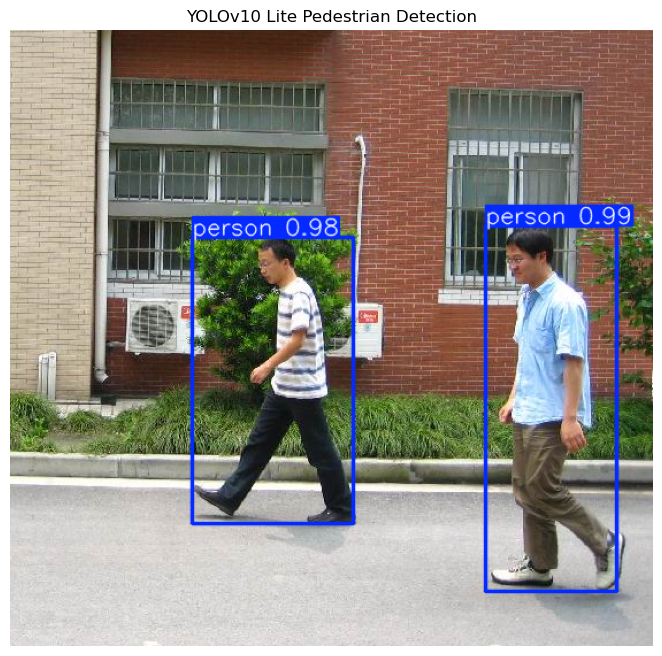

In [23]:
import matplotlib.pyplot as plt
import cv2

# Test image
image_path = r"C:\Users\HP\anaconda3\nitw impl\project\dataset\PNGImages\FudanPed00001.png"

# Detection
results = best_model(image_path)

# Draw boxes
annotated_frame = results[0].plot()

# Convert BGR to RGB
annotated_frame = cv2.cvtColor(
    annotated_frame,
    cv2.COLOR_BGR2RGB
)

# Show result
plt.figure(figsize=(12,8))
plt.imshow(annotated_frame)
plt.axis("off")
plt.title("YOLOv10 Lite Pedestrian Detection")
plt.show()

In [24]:
from ultralytics import YOLO

# Load YOLOv10 Lite trained model
model = YOLO(r"runs/detect/train-2/weights/best.pt")

# Run detection on all images
results = model.predict(
    source=r"C:\Users\HP\anaconda3\nitw impl\project\dataset\PNGImages",
    save=True,
    show=True
)

print("Detection completed")


image 1/170 C:\Users\HP\anaconda3\nitw impl\project\dataset\PNGImages\FudanPed00001.png: 640x640 2 persons, 236.8ms
image 2/170 C:\Users\HP\anaconda3\nitw impl\project\dataset\PNGImages\FudanPed00002.png: 608x640 2 persons, 320.8ms
image 3/170 C:\Users\HP\anaconda3\nitw impl\project\dataset\PNGImages\FudanPed00003.png: 608x640 1 person, 200.0ms
image 4/170 C:\Users\HP\anaconda3\nitw impl\project\dataset\PNGImages\FudanPed00004.png: 640x640 3 persons, 196.3ms
image 5/170 C:\Users\HP\anaconda3\nitw impl\project\dataset\PNGImages\FudanPed00005.png: 640x640 2 persons, 354.7ms
image 6/170 C:\Users\HP\anaconda3\nitw impl\project\dataset\PNGImages\FudanPed00006.png: 640x608 2 persons, 506.9ms
image 7/170 C:\Users\HP\anaconda3\nitw impl\project\dataset\PNGImages\FudanPed00007.png: 480x640 3 persons, 415.0ms
image 8/170 C:\Users\HP\anaconda3\nitw impl\project\dataset\PNGImages\FudanPed00008.png: 640x576 2 persons, 426.0ms
image 9/170 C:\Users\HP\anaconda3\nitw impl\project\dataset\PNGImages\Fu